<a href="https://colab.research.google.com/github/AllaYermilko/melbourne-housing/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot

# Крок 1. Завантаження даних

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [2]:
FILE_IN = "https://raw.githubusercontent.com/AllaYermilko/Melbourne-housing/refs/heads/main/data/melb_data.csv"
df = pd.read_csv(FILE_IN)

In [3]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


# Крок 2. Перший огляд

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [5]:
df.shape

(13580, 21)

In [6]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [7]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2',
       'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount'],
      dtype='object')

In [8]:
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [9]:
(df.isna().mean() * 100).round(1).sort_values(ascending=False)

,0
BuildingArea,47.5
YearBuilt,39.6
CouncilArea,10.1
Car,0.5
Suburb,0.0
Price,0.0
Type,0.0
Rooms,0.0
Address,0.0
Distance,0.0


In [10]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [11]:
# зводимо типи і частку пропусків в одну таблицю
info = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропусків_%": (df.isna().mean() * 100).round(1),
})
print(info.sort_values("пропусків_%", ascending=False))
df.describe()       # подивіться на min/max

                   тип  пропусків_%
BuildingArea   float64         47.5
YearBuilt      float64         39.6
CouncilArea     object         10.1
Car            float64          0.5
Suburb          object          0.0
Price          float64          0.0
Type            object          0.0
Rooms            int64          0.0
Address         object          0.0
Distance       float64          0.0
Method          object          0.0
Date            object          0.0
SellerG         object          0.0
Bathroom       float64          0.0
Bedroom2       float64          0.0
Postcode       float64          0.0
Landsize       float64          0.0
Lattitude      float64          0.0
Longtitude     float64          0.0
Regionname      object          0.0
Propertycount  float64          0.0


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


**Найбільше пропусків у стовпцях:**
- BuildingArea (47.5%)  
- YearBuilt (39.6%).  

Також є 10.1% пропусків у CouncilArea.

**Типи даних:**  
Стовпець Date визначився як текст (object), хоча має бути datetime.

# Крок 3. Очищення

In [12]:
clean = df.copy()
if 'Unnamed: 0' in clean.columns:
  clean = clean.drop(columns=['Unnamed: 0'])
  print('Column with index - deleted')

# стовпців типу Unnamed немає

In [13]:
# створюємо копію
clean = df.copy()

# виправляємо формат дати
clean["Date"] = pd.to_datetime(clean["Date"], dayfirst=True)

# замінюємо нулі у площах на пропуски (NaN)
for col in ["Landsize", "BuildingArea"]:
    clean.loc[clean[col] == 0, col] = np.nan

# замінюємо помилковий рік побудови на пропуски (NaN)
clean.loc[clean["YearBuilt"] < 1800, "YearBuilt"] = np.nan

# видаляємо дублікати рядків
clean = clean.drop_duplicates()

# перевірка та вивід результатів
df_origin = df
df_clean = clean

print("Cleaning results:\n")
print("=" * 20, "\n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df_clean)}")
print(f"Loss: {len(df_origin) - len(df_clean)} ({(len(df_origin) - len(df_clean)) / len(df_origin) * 100:.1f}%)")

print("\n---Residual gaps:---")
remaining = df_clean.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\n---Data types after cleanup:---")
display(df_clean.dtypes)

print("\n---Statistics ---")
# показуємо статистику для головних стовпців нової таблиці
print(df_clean[['Rooms', 'Price', 'Landsize']].describe().round(2))

Cleaning results:


Rows before: 13580
Rows after: 13580
Loss: 0 (0.0%)

---Residual gaps:---
Car               62
Landsize        1939
BuildingArea    6467
YearBuilt       5376
CouncilArea     1369
dtype: int64

---Data types after cleanup:---


,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,float64



---Statistics ---
          Rooms       Price   Landsize
count  13580.00    13580.00   11641.00
mean       2.94  1075684.08     651.43
std        0.96   639310.72    4303.22
min        1.00    85000.00       1.00
25%        2.00   650000.00     270.00
50%        3.00   903000.00     533.00
75%        3.00  1330000.00     676.00
max       10.00  9000000.00  433014.00


In [14]:
clean.shape

(13580, 21)

# Крок 4. Дослідження (EDA)

# 1) розподіл ціни: побудуйте гістограму Price

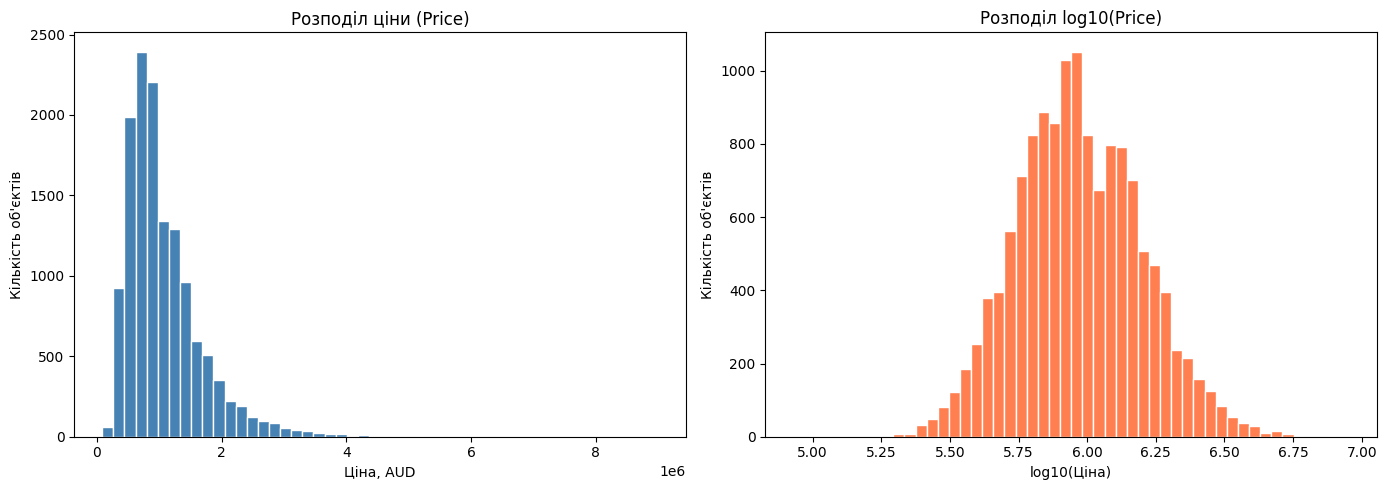

In [15]:
# 1) розподіл ціни: побудуйте гістограму Price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ліворуч — звичайна ціна
axes[0].hist(df["Price"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Розподіл ціни (Price)")
axes[0].set_xlabel("Ціна, AUD")
axes[0].set_ylabel("Кількість об'єктів")

# 2) гістограма логарифма ціни для порівняння

# Праворуч — логарифм ціни
axes[1].hist(np.log10(clean["Price"].dropna()), bins=50, color="coral", edgecolor="white")
axes[1].set_title("Розподіл log10(Price)")
axes[1].set_xlabel("log10(Ціна)")
axes[1].set_ylabel("Кількість об'єктів")

plt.tight_layout()
plt.show()

За графіком звичайної ціни видно, що розподіл має сильний перекіс вліво. Більшість будинків коштують близько 1 мільйона, але довгий "хвіст" праворуч показує наявність поодиноких елітних об'єктів із дуже високою ціною.  

Після логарифмування розподіл цін став симетричним і схожим на дзвін. Перетворення на логарифм усуває сильний перекіс цін, що критично важливо для правильної роботи та високої точності моделей машинного навчання.

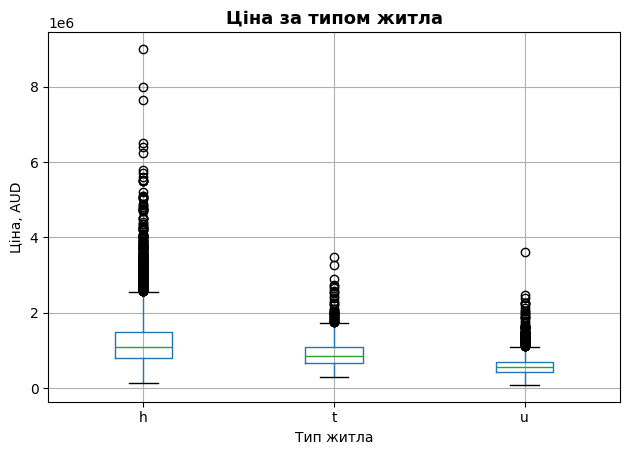

In [16]:
# 3) ціна за типом житла: boxplot

clean.boxplot(column="Price", by="Type")

plt.title('Ціна за типом житла', fontsize=13, fontweight='bold')

plt.xlabel('Тип житла')
plt.ylabel('Ціна, AUD')
plt.suptitle('')
plt.tight_layout()
plt.show()


Найдорожчий тип житла — це будинки (h), вони мають найвищу медіанну ціну.  Найдешевший тип — це квартири (u).  
Викиди: У кожному типі житла є багато аномально дорогих об'єктів (елітна нерухомість).

In [17]:
# 4) кореляція числових ознак ІЗ ЦІНОЮ:

num = clean.select_dtypes("number")  #    - візьміть лише числові стовпці: num = clean.select_dtypes("number")
matrix = num.corr()   #    - порахуйте num.corr()
price_corr = matrix["Price"].drop("Price").sort_values(key=abs, ascending=False)   #    - візьміть стовпець ["Price"], приберіть сам Price (.drop("Price")), відсортуйте за модулем: .sort_values(key=abs, ascending=False)

print("Кореляція числових ознак із ціною:")   #  - надрукуйте і прочитайте: що найсильніше пов'язане з ціною?
print(price_corr)

Кореляція числових ознак із ціною:
Rooms            0.496634
Bedroom2         0.475951
Bathroom         0.467038
YearBuilt       -0.331828
Car              0.238979
Lattitude       -0.212934
Longtitude       0.203656
Distance        -0.162522
Postcode         0.107867
BuildingArea     0.091576
Propertycount   -0.042153
Landsize         0.023258
Name: Price, dtype: float64


- Найсильніший позитивний зв'язок мають: Rooms (0.50), Bedroom2 (0.48), Bathroom (0.47). Чим більше кімнат в помешканні, тим вища ціна на нього.  
- Негативний зв'язок: YearBuilt (-0.33). Наявність мінуса означає зворотну залежність. В даних ми бачимо, що чим новіший рік побудови, тим ціна нижча. Це може бути аномалія, яку треба дослідити, або ж у Мельбурні старі історичні будинки цінуються вище за новобудови.  
Логічний мінус: Distance (-0.16). Чим більша відстань до центру міста, тим дешевша нерухомість.  
- Слабкий зв'язок: Landsize (0.02) та Propertycount (-0.04) майже не впливають на ціну. Кореляція майже нульова. Це означає, що сам по собі розмір ділянки чи кількість нерухомості в районі майже не визначають фінальну вартість об'єкта.

In [18]:
# 5) пошук майже-дублікатів: подивіться на повну матрицю кореляцій
#    - знайдіть пари з дуже високим зв'язком (наприклад, Rooms і Bedroom2)
num.corr().round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.00,0.50,0.29,0.06,0.94,0.59,0.41,0.00,0.12,-0.07,0.02,0.10,-0.08
Price,0.50,1.00,-0.16,0.11,0.48,0.47,0.24,0.02,0.09,-0.33,-0.21,0.20,-0.04
Distance,0.29,-0.16,1.00,0.43,0.30,0.13,0.26,0.01,0.10,0.25,-0.13,0.24,-0.05
Postcode,0.06,0.11,0.43,1.00,0.06,0.11,0.05,0.03,0.06,0.04,-0.41,0.45,0.06
Bedroom2,0.94,0.48,0.30,0.06,1.00,0.58,0.41,0.00,0.12,-0.05,0.02,0.10,-0.08
Bathroom,0.59,0.47,0.13,0.11,0.58,1.00,0.32,0.03,0.11,0.15,-0.07,0.12,-0.05
Car,0.41,0.24,0.26,0.05,0.41,0.32,1.00,0.02,0.10,0.11,-0.00,0.06,-0.02
Landsize,0.00,0.02,0.01,0.03,0.00,0.03,0.02,1.00,0.50,0.08,0.01,0.01,-0.00
BuildingArea,0.12,0.09,0.10,0.06,0.12,0.11,0.10,0.50,1.00,0.02,0.04,-0.02,-0.03
YearBuilt,-0.07,-0.33,0.25,0.04,-0.05,0.15,0.11,0.08,0.02,1.00,0.06,-0.00,0.01


Головна пара-дублікат: Rooms та Bedroom2 (кореляція 0.94, майже повний зв'язок). Кількість кімнат та кількість спалень несуть майже однакову інформацію. Вони сильно дублюють один одного. Один із них варто видалити перед моделюванням.  
Пари з високим зв'язком: Rooms та Bathroom (кореляція 0.59, сильна залежність). Ця пара має прямий логічний зв'язок. Чим більше в будинку кімнат, тим більше в ньому ванних кімнат.  
Bedroom2 та Bathroom (кореляція 0.58). Аналогічно — велика кількість спалень означає наявність кількох санвузлів.  
Landsize та BuildingArea (кореляція 0.50). Ця пара має помірний прямий зв'язок. На великих ділянках землі зазвичай будують більші за площею будинки.

1. Згідно з графіком boxplot, найдорожчим типом житла є окремі будинки (h), які мають найвищу середню вартість. Квартири (u), навпаки, є найдешевшим і найдоступнішим варіантом.  
2. Матриця кореляції показує негативний зв'язок між ціною та відстанню до центру (Distance = -0.16). Чим далі житло від центру міста, тим нижчою є його ціна.  
3. Такі ознаки, як Rooms та Bedroom2 мають критично високу кореляцію — 0.94. Вони майже повністю дублюють інформацію один одного, тому одну з них варто видалити перед навчанням моделей.

# Крок 5. Нові ознаки (feature engineering)

In [19]:
fe = clean.copy()
# 1) частини дати продажу
fe["sale_year"]  = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

# 2) вік будинку на момент продажу
fe["house_age"] = fe["sale_year"] - fe["YearBuilt"]
fe.loc[fe["house_age"] < 0, "house_age"] = np.nan   #    - підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan

# 3) прапорці наявності (пропуск як сигнал)
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)   #    - для BuildingArea:
fe["has_yearbuilt"] = fe["YearBuilt"].notna().astype(int)   #    - зробіть так само has_yearbuilt для YearBuilt

# 4) частотне кодування району Suburb
fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())

# 5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])

columns_to_drop = [
    "Bedroom2",
    "Address",
    "SellerG",
    "Suburb",
    "Date",
    "CouncilArea"
]

fe = fe.drop(columns=columns_to_drop)

# Виводимо фінальний розмір таблиці
print(f'✓ Фінальний датасет: {fe.shape}')
print('\nПерші рядки з новими колонками:')
display(fe[['sale_year', 'sale_month', 'house_age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']].head())


✓ Фінальний датасет: (13580, 21)

Перші рядки з новими колонками:


,sale_year,sale_month,house_age,has_buildingarea,has_yearbuilt,suburb_freq
0,2016,12,NaN,0,0,56
1,2016,2,116.0,1,1,56
2,2017,3,117.0,1,1,56
3,2017,3,NaN,0,0,56
4,2016,6,2.0,1,1,56


# Крок 6. Підготовка до моделювання

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder   # кодування категорій

# 1) ціль і ознаки
X = fe.drop(columns=['Price'])    #    - X = усе інше (приберіть Price)
y = fe['Price']   #    - y = ціна (стовпець Price)

# 2) поділіть стовпці на категорійні і числові
cat_cols = cat_cols = ['Type', 'Method', 'Regionname']     #    - cat_cols = [...]   # текстові: Type, Method, Regionname, CouncilArea
num_cols = X.select_dtypes(include=['number']).columns.tolist()    #    - num_cols = [...]   решта числових (усе, що не в cat_cols)

# num_cols = [
#     'Rooms', 'Distance', 'Postcode', 'Bathroom', 'Car',
#     'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude',
#     'Longtitude', 'Propertycount', 'sale_year', 'sale_month',
#     'house_age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq'
# ]

# 3) опишіть підготовку через ColumnTransformer:
preprocess = ColumnTransformer([
       ("num", SimpleImputer(strategy="median"), num_cols),
       ("cat", Pipeline([
       ("imp", SimpleImputer(strategy="most_frequent")),
       ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

print("ColumnTransformer успішно створений!")

ColumnTransformer успішно створений!


In [21]:
# 4) поділіть дані на train і test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Тренувальні ознаки (X_train): {X_train.shape}")

Тренувальні ознаки (X_train): (10864, 20)


# Крок 7. Модель і прогноз

In [22]:
from sklearn.dummy import DummyRegressor                 # базова лінія
from sklearn.linear_model import LinearRegression        # проста модель
from sklearn.ensemble import RandomForestRegressor       # складніша модель
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Зручно зробити невелику функцію, що навчає модель і друкує метрики:
def evaluate(model, name):
    print(f"\n--- Оцінка моделі: {name} ---")

    # 1) Склеюємо підготовку і модель
    pipe = Pipeline([("prep", preprocess), ("model", model)])

    # 2) Навчаємо на тренувальних даних
    pipe.fit(X_train, y_train)

    # 3) Робимо прогноз на тестових даних
    pred = pipe.predict(X_test)

    # 4) Рахуємо метрики
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    # Виводимо результати на екран
    print(f"MAE (Середня помилка):  {mae:.2f} доларів")
    print(f"RMSE (Великі промахи): {rmse:.2f}")
    print(f"R² (Якість моделі):    {r2:.4f}")

    # 5) Повертаємо готовий конвеєр
    return pipe


# 1. Запуск для базової моделі (просто середнє значення)
dummy_pipe = evaluate(DummyRegressor(strategy="mean"), "Dummy Baseline")

# 2. Запуск для Лінійної регресії
lr_pipe = evaluate(LinearRegression(), "Linear Regression")

# 3. Запуск для RandomForest
rf_pipe = evaluate(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), "Random Forest")


--- Оцінка моделі: Dummy Baseline ---
MAE (Середня помилка):  461257.73 доларів
RMSE (Великі промахи): 630259.30
R² (Якість моделі):    -0.0000

--- Оцінка моделі: Linear Regression ---
MAE (Середня помилка):  264908.97 доларів
RMSE (Великі промахи): 385396.29
R² (Якість моделі):    0.6261

--- Оцінка моделі: Random Forest ---
MAE (Середня помилка):  163320.22 доларів
RMSE (Великі промахи): 269557.39
R² (Якість моделі):    0.8171


Dummy_pipe дає незадовільну точність. Якщо взагалі не враховувати характеристики нерухомості (площу, район тощо), а просто орієнтуєнтуватися на середню ціну по ринку, то помилка прогнозу є критичною — майже 461 тис. дол.  
Linear Regression бачить лише загальні тренди. Ця модель враховує параметри об'єктів, але шукає лише прямі залежності. Вона пояснює 63% коливань цін, але середня помилка висока: близько 265 тисяч доларів.  
Модель Random Forest показала найкращі результати. Вона успішно знаходить складні комбінації факторів у даних. Модель правильно описує ринок на 82% (R² = 0.8171) і є найточнішою: середня помилка знижується до 163 тисяч доларів.
  
Для практичного використання та інтеграції в продукт варто обрати модель Random Forest, оскільки вона зменшує фінансові ризики та помилки прогнозування у півтора раза порівняно з лінійною регресією.

In [24]:
# Важливість ознак у лісу:
#  - у навченого лісу візьміть model.feature_importances_
rf_model = rf_pipe.named_steps["model"]

#  - назви стовпців після One-Hot дістаньте через get_feature_names_out
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()

#  - відсортуйте і подивіться топ ознак
importances_df = pd.DataFrame({
    "Ознака": feature_names,
    "Важливість": rf_model.feature_importances_
})

top_features = importances_df.sort_values(by="Важливість", ascending=False).head(10)

print("\n--- ТОП-10 найважливіших ознак для ціни ---\n")
print(top_features.to_string(index=False))




--- ТОП-10 найважливіших ознак для ціни ---

                               Ознака  Важливість
cat__Regionname_Southern Metropolitan    0.208644
                           num__Rooms    0.174070
                        num__Distance    0.137574
                          cat__Type_u    0.088961
                        num__Landsize    0.078823
                      num__Longtitude    0.054358
                    num__BuildingArea    0.047846
                       num__Lattitude    0.040323
                        num__Bathroom    0.030313
                   num__Propertycount    0.017971


1. Локація або cat__Regionname_Southern Metropolitan (21% важливості ознаки): це найголовніший фактор для моделі. Якщо будинок знаходиться у цьому районі, його ціна автоматично здорожчує.  
2. Кількість кімнат або num__Rooms (17.4% впливу): другий за важливістю фактор. Чим більше кімнат в будинку, тим дорожче він коштує. Це головний показник розміру житла для моделі.  
3. Відстань до центру міста або num__Distance (13.8% впливу). Чим ближче об'єкт до центру міста, тим він дорожчий. Кожен кілометр віддалення знижує ціну.  
4. Тип житла(квартири або таунхауси) або cat__Type_u (8.9% впливу). Модель виділила цю ознаку, бо квартири зазвичай значно дешевші за окремі великі будинки.
5. Розмір ділянки землі або num__Landsize (7.9% впливу): наявність власної прибудинкової території чи земельної ділянки додають будинку значущої вартості.  
6. Географічні координати або num__Longtitude (5.4%) та num__Lattitude (4.0%)(Довгота та Широта): точне розташування на карті теж дуже важливе. Це допомагає моделі точніше розуміти мікрорайони всередині великих регіонів (наприклад, близькість до моря чи елітних шкіл).  
7. Площа будівлі та ванни num__BuildingArea (4.8%) та num__Bathroom (3.0%): чиста площа самих кімнат та кількість ванних кімнат теж докидають ціни, але вони мають менше значення, ніж загальна кількість кімнат (Rooms) чи район.

# Прогноз для прикладу

In [28]:
# 1. візьміть один рядок із тесту як "новий" об'єкт
example = X_test.iloc[[0]]   #  - example = X_test.iloc[[0]]

# 2. зробіть прогноз навченим лісом і порівняйте зі справжньою ціною:
# Він повертає логарифм ціни, тому ми одразу обгортаємо його в np.exp()
predict_price = rf_pipe.predict(example)[0]
real_price = y_test.iloc[0]

print("--- Перевірка моделі на одному реальному прикладі ---")
print(f"Прогноз моделі:   {predict_price:,.2f} доларів")
print(f"Справжня ціна:    {real_price:,.2f} доларів")
print(f"Різниця (помилка): {abs(predict_price - real_price):,.2f} доларів")


--- Перевірка моделі на одному реальному прикладі ---
Прогноз моделі:   2,127,990.00 доларів
Справжня ціна:    2,600,000.00 доларів
Різниця (помилка): 472,010.00 доларів


Модель працює корректно. Для обраного будинку модель передбачила вартість близько 2.13 млн доларів, тоді як його реальна ціна становить 2.60 млн доларів. Модель правильно зрозуміла порядок цін та визначила, що це елітна, дорога нерухомість.  
Різниця між прогнозом та реальністю склала 472 010 доларів. На перший погляд, це велика сума, але для об'єктів вартістю понад 2.5 мільйони така похибка є нормальною. Модель схильна трохи занижувати ціну на дуже дорогі будинки, тому що «Випадковий ліс» намагається усереднювати екстремальні значення.  
На прикладі цього будинку видно, чому наша загальна помилка великих промахів (RMSE) виявилася такою високою. На звичайних об'єктах модель помиляється в середньому на 163 тисячі (MAE). Але на дуже дорогих будинках за 2.6 мільйони модель промахується значно сильніше — аж на 472 тисячі. Саме такі поодинокі великі помилки на дорогих об'єктах і тягнуть показник великих промахів (RMSE) вгору.